# Chapter 8 - Support Vector Machine (SVM)

## Binary SVM Classification

Accuracy: 1.0


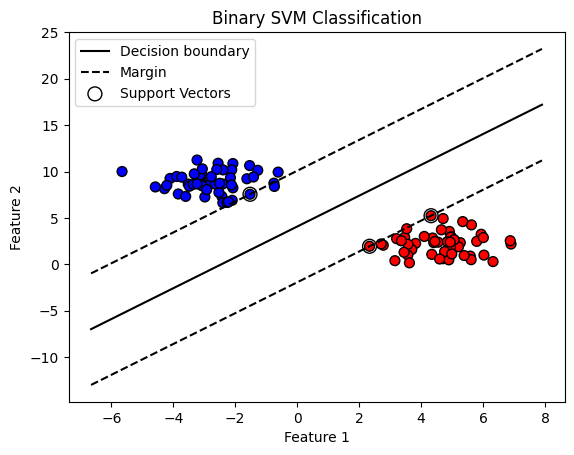

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Bước 1: Tạo dữ liệu giả lập nhị phân 2D
# cluster_std=1.2
# Độ lệch chuẩn của từng cụm. Giá trị càng lớn, các điểm dữ liệu càng lan rộng, cụm càng "mờ" và phân tách khó hơn.
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bước 2: Tạo mô hình SVM tuyến tính
model = SVC(kernel='linear', C=1.0)  # kernel='linear' cho SVM tuyến tính
model.fit(X_train, y_train)

# Bước 3: Dự đoán và đánh giá
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Bước 4: Vẽ dữ liệu và siêu phẳng phân lớp
def plot_svm(X, y, model):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=50, edgecolors='k')
    
    # Lấy trọng số và bias
    w = model.coef_[0]
    b = model.intercept_[0]
    
    # Vẽ siêu phẳng: w0*x + w1*y + b = 0 -> y = -(w0*x + b)/w1
    x_plot = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    y_plot = -(w[0]*x_plot + b)/w[1]
    plt.plot(x_plot, y_plot, 'k-', label='Decision boundary')
    
    # Vẽ margin
    margin = 1/np.linalg.norm(w)
    y_margin_up = y_plot + np.sqrt(1 + (w[0]/w[1])**2)*margin
    y_margin_down = y_plot - np.sqrt(1 + (w[0]/w[1])**2)*margin
    plt.plot(x_plot, y_margin_up, 'k--', label='Margin')
    plt.plot(x_plot, y_margin_down, 'k--')
    
    # Vẽ support vectors
    plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1], s=100,
                facecolors='none', edgecolors='k', label='Support Vectors')
    
    plt.legend()
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Binary SVM Classification')
    plt.show()

plot_svm(X, y, model)


## Multi-class SVM Classification
While the original SVM is binary, scikit-learn automatically extends it to multi-class using One-vs-Rest (OvR) or One-vs-One (OvO):

Accuracy: 1.0


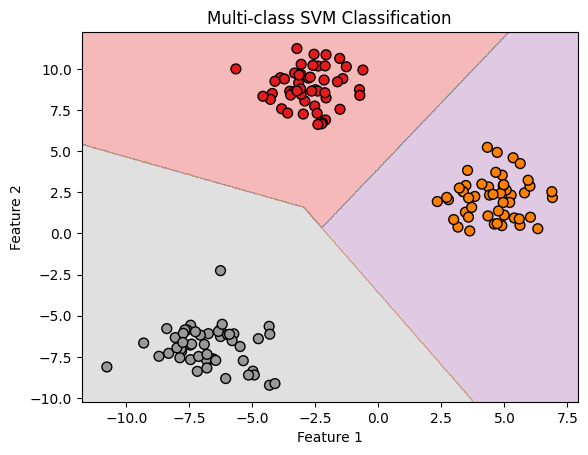

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Bước 1: Tạo dữ liệu 3 lớp (3 centers)
X, y = datasets.make_blobs(n_samples=150, centers=3, cluster_std=1.2, random_state=42)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bước 2: Tạo mô hình SVM tuyến tính
# Vẫn dùng SVM nhị phân, nhưng scikit-learn tự động mở rộng thành đa lớp bằng OvR.
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

# Bước 3: Dự đoán và đánh giá
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Bước 4: Vẽ dữ liệu và siêu phẳng phân lớp (chỉ minh họa trên 2D)
def plot_svm_multi(X, y, model):
    # Tạo lưới để dự đoán
    x_min, x_max = X[:, 0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Vẽ vùng phân lớp
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='Set1', edgecolors='k')
    plt.title('Multi-class SVM Classification')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_svm_multi(X, y, model)

## Nonlinear binary SVM classification

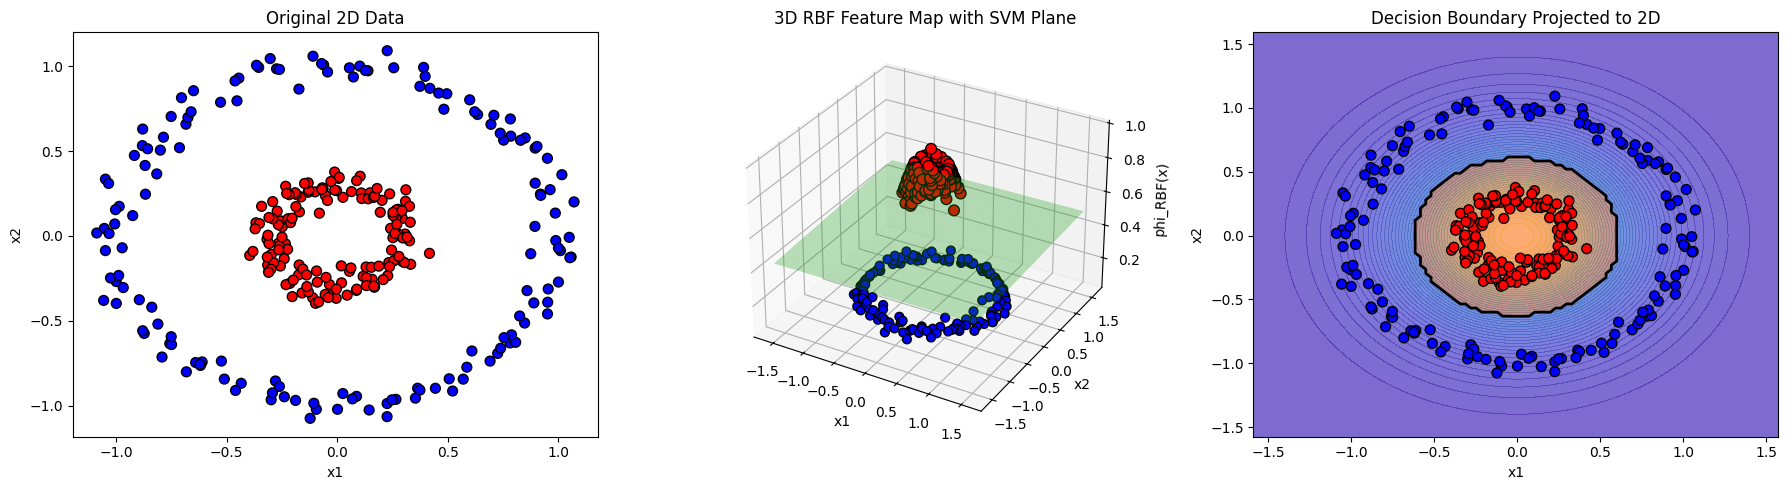

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles
from mpl_toolkits.mplot3d import Axes3D

# Tạo dữ liệu phi tuyến
X, y = make_circles(n_samples=300, factor=0.3, noise=0.05, random_state=0)

# Hàm ánh xạ RBF sang không gian 3D
def rbf_feature_map(X, gamma=2.0):
    r = np.sum(X**2, axis=1)
    Z = np.exp(-gamma * r)
    return Z

gamma = 2.0
Z = rbf_feature_map(X, gamma)
X3 = np.column_stack([X, Z])

# Huấn luyện SVM tuyến tính trong không gian 3D
clf3d = svm.SVC(kernel='linear')
clf3d.fit(X3, y)

# Lấy tham số siêu phẳng w^T.x + b
w = clf3d.coef_[0]
b = clf3d.intercept_[0]

# Lưới mặt phẳng
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100)
)
zz = -(w[0] * xx + w[1] * yy + b) / w[2]

# Xác định điểm trên/dưới siêu phẳng
plane_z = -(w[0]*X[:,0] + w[1]*X[:,1] + b)/w[2]
below_mask = Z < plane_z
above_mask = Z >= plane_z

# Đảm bảo dữ liệu nằm trên thực sự nằm trên siêu phẳng
epsilon = 0.05  # khoảng cách nhỏ
Z_above = np.maximum(Z, plane_z + epsilon)
Z_below = np.minimum(Z, plane_z - epsilon)

# Tạo figure với 3 subplots
fig = plt.figure(figsize=(18,5))

# Hình 1: dữ liệu gốc 2D
ax1 = fig.add_subplot(131)
ax1.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', s=50)
ax1.set_title("Original 2D Data")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")

# Hình 2: dữ liệu RBF 3D với siêu phẳng
ax2 = fig.add_subplot(132, projection='3d')

# 1. Dữ liệu dưới
ax2.scatter(X[below_mask,0], X[below_mask,1], Z_below[below_mask],
            color='blue', edgecolor='k', s=40, alpha=1.0)

# 2. Siêu phẳng
ax2.plot_surface(xx, yy, zz, color=(0.1,0.8,0.1), alpha=0.3, rstride=1, cstride=1, linewidth=0, antialiased=True)

# 3. Dữ liệu trên
ax2.scatter(X[above_mask,0], X[above_mask,1], Z_above[above_mask],
            color='red', edgecolor='k', s=60, alpha=1.0)

ax2.set_title("3D RBF Feature Map with SVM Plane")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("phi_RBF(x)")

# Hình 3: chiếu 2D với gradient phi_RBF + dự đoán lớp
ax3 = fig.add_subplot(133)

# Tạo grid 2D cho dự đoán
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_grid = np.exp(-gamma * np.sum(grid_points**2, axis=1))
X_grid3 = np.column_stack([grid_points, Z_grid])
pred_grid = clf3d.predict(X_grid3).reshape(xx.shape)

# Gradient phi_RBF
Z_surface = np.exp(-gamma * (xx**2 + yy**2))
ax3.contourf(xx, yy, Z_surface, levels=50, cmap='viridis', alpha=0.4)

# Vùng dự đoán lớp phi tuyến
ax3.contourf(xx, yy, pred_grid, levels=[-0.1,0.5,1.1], colors=['blue','red'], alpha=0.3)

# Contour đen ranh giới
ax3.contour(xx, yy, pred_grid, levels=[0.5], colors='k', linewidths=2)

# Vẽ điểm dữ liệu
ax3.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', s=50)

ax3.set_title("Decision Boundary Projected to 2D")
ax3.set_xlabel("x1")
ax3.set_ylabel("x2")

plt.tight_layout()
plt.show()

## Create interactive charts with plotly

In [4]:
# Cài đặt thư viện
%pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.5 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import plotly.graph_objects as go
from sklearn import svm
from sklearn.datasets import make_circles

# -------------------------------
# 1. Tạo dữ liệu phi tuyến
# -------------------------------
X, y = make_circles(n_samples=300, factor=0.3, noise=0.05, random_state=0)

# Hàm ánh xạ RBF sang 3D
def rbf_feature_map(X, gamma=2.0):
    r = np.sum(X**2, axis=1)
    return np.exp(-gamma * r)

gamma = 2.0
Z = rbf_feature_map(X, gamma)
X3 = np.column_stack([X, Z])

# Huấn luyện SVM tuyến tính trong không gian 3D
clf3d = svm.SVC(kernel='linear')
clf3d.fit(X3, y)

# Lấy tham số siêu phẳng w^T.x + b
w = clf3d.coef_[0]
b = clf3d.intercept_[0]

# -------------------------------
# 2. Lưới siêu phẳng
# -------------------------------
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 80),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 80)
)
zz = -(w[0]*xx + w[1]*yy + b)/w[2]

# Xác định điểm trên/dưới siêu phẳng
plane_z = -(w[0]*X[:,0] + w[1]*X[:,1] + b)/w[2]
below_mask = Z < plane_z
above_mask = Z >= plane_z

# Đảm bảo dữ liệu trên thật sự cao hơn surface
epsilon = 0.5
Z_above = np.maximum(Z, plane_z + epsilon)
Z_below = np.minimum(Z, plane_z - 0.1)

# -------------------------------
# 3. Scatter 3D + Surface đẹp mắt
# -------------------------------
trace_below = go.Scatter3d(
    x=X[below_mask,0], y=X[below_mask,1], z=Z_below[below_mask],
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.8),
    name='Below Plane'
)

trace_above = go.Scatter3d(
    x=X[above_mask,0], y=X[above_mask,1], z=Z_above[above_mask],
    mode='markers',
    marker=dict(size=6, color='red', opacity=0.9),
    name='Above Plane'
)

trace_surface = go.Surface(
    x=xx, y=yy, z=zz,
    colorscale=[[0,'green'],[1,'green']],
    opacity=0.35,
    name='SVM Plane',
    showscale=False
)

fig3d = go.Figure(data=[trace_surface, trace_below, trace_above])

# Tùy chỉnh layout đẹp mắt
fig3d.update_layout(
    title="3D RBF Feature Map with SVM Plane (Interactive)",
    scene=dict(
        xaxis=dict(title='x1', range=[-2, 2], backgroundcolor="rgb(240,240,240)"),
        yaxis=dict(title='x2', range=[-2, 2], backgroundcolor="rgb(240,240,240)"),
        zaxis=dict(title='phi_RBF(x)', range=[-0.2, 2], backgroundcolor="rgb(240,240,240)"),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
        aspectratio=dict(x=1, y=1, z=0.8)
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# -------------------------------
# 4. Chiếu 2D với gradient phi_RBF + ranh giới
# -------------------------------
Z_surface2D = np.exp(-gamma * (xx**2 + yy**2))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_grid = np.exp(-gamma * np.sum(grid_points**2, axis=1))
X_grid3 = np.column_stack([grid_points, Z_grid])
pred_grid = clf3d.predict(X_grid3).reshape(xx.shape)

fig2d = go.Figure()

# Gradient phi_RBF
fig2d.add_trace(go.Contour(
    z=Z_surface2D,
    x=xx[0,:], y=yy[:,0],
    colorscale='Viridis',
    opacity=0.4,
    showscale=False,
    name='phi_RBF Gradient'
))

# Vùng dự đoán lớp
fig2d.add_trace(go.Contour(
    z=pred_grid,
    x=xx[0,:], y=yy[:,0],
    colorscale=[[0,'blue'],[1,'red']],
    opacity=0.3,
    showscale=False,
    contours=dict(start=0,end=1,size=1),
    name='Predicted Class'
))

# Ranh giới contour
fig2d.add_trace(go.Contour(
    z=pred_grid,
    x=xx[0,:], y=yy[:,0],
    contours=dict(start=0.5,end=0.5),
    line=dict(color='black', width=2),
    showscale=False,
    name='Decision Boundary'
))

# Điểm dữ liệu
fig2d.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1], mode='markers',
    marker=dict(color=['red' if label==1 else 'blue' for label in y],
                line=dict(color='black', width=1), size=6),
    name='Data Points'
))

fig2d.update_layout(
    title="Decision Boundary Projected to 2D",
    xaxis_title='x1', yaxis_title='x2',
    width=700, height=700,
    margin=dict(l=50, r=50, t=50, b=50)
)
fig2d.show()
